# Production RAG — Модуль 2: Embeddings

## Что такое embeddings?

**Embedding** — это вектор (массив чисел), который кодирует **смысл** текста.  
Похожие по смыслу тексты → близкие векторы.

```
"Java разработчик"     → [0.8, 0.2, -0.1, 0.5, ...] ─┐
"Spring Boot developer" → [0.7, 0.3, -0.1, 0.4, ...] ─┤ близко (cosine ~ 0.95)
"Рецепт борща"          → [-0.3, 0.9, 0.6, -0.2, ...]  далеко (cosine ~ 0.1)
```

### Java аналогия:

```java
// Embedding — это как hashCode(), но сохраняет семантику

// hashCode: похожие строки → разные хеши
"cat".hashCode();  // 98262
"Cat".hashCode();  // 66642
"dog".hashCode();  // 99644  — не ближе чем "Cat"!

// Embedding: похожие по смыслу → близкие векторы
embed("cat");  // [0.2, 0.8, ...]
embed("Cat");  // [0.2, 0.8, ...] — почти идентичен
embed("dog");  // [0.3, 0.7, ...] — близко (оба животные)
embed("SQL");  // [-0.5, 0.1, ...] — далеко
```

### Что изучим:
1. Как работают embeddings под капотом
2. Метрики сходства: cosine, dot product, euclidean
3. Модели: HuggingFace, OpenAI, multilingual
4. Бенчмарк: какая модель лучше для твоих данных
5. Практика: визуализация embedding space

In [1]:
# Пакеты уже установлены в venv lc-academy-env:
# pip install sentence-transformers langchain langchain-community langchain-huggingface numpy matplotlib scikit-learn
print("Пакеты загружены из venv")

Пакеты загружены из venv


---
## 1. Embeddings с нуля: что внутри вектора

Embedding модель — это нейросеть (обычно Transformer), обученная так:
- Похожие предложения → близкие векторы
- Разные предложения → далёкие векторы

```
Текст → Tokenizer → Transformer → Pooling → Вектор [384 чисел]
```

```java
// Аналогия: Feature extraction в ML
// Вместо ручных фичей (длина, кол-во слов) —
// нейросеть сама выучила 384 "фичи" текста
float[] features = neuralNet.extractFeatures(text); // [384]
```

In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np
%matplotlib inline

# Загружаем модель напрямую (без LangChain обёртки)
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Создаём embedding
text = "Spring Boot упрощает создание микросервисов"
embedding = model.encode(text)

print(f"Текст: {text}")
print(f"Тип: {type(embedding)}")
print(f"Размерность: {embedding.shape}")
print(f"Первые 10 значений: {embedding[:10].round(4)}")
print(f"Мин: {embedding.min():.4f}, Макс: {embedding.max():.4f}")
print(f"Норма (длина вектора): {np.linalg.norm(embedding):.4f}")

C:\Users\Ruslan\ai-learning\langchain-academy\lc-academy-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Текст: Spring Boot упрощает создание микросервисов
Тип: <class 'numpy.ndarray'>
Размерность: (384,)
Первые 10 значений: [-0.032   0.0359 -0.02   -0.0305 -0.0105  0.0405  0.0677  0.0676 -0.0495
  0.0101]
Мин: -0.1579, Макс: 0.1414
Норма (длина вектора): 1.0000


---
## 2. Метрики сходства

Как измерить «похожесть» двух векторов?

### Cosine Similarity (самая популярная)
Угол между векторами. Не зависит от длины вектора.
- `1.0` — идентичные
- `0.0` — ортогональные (не связаны)
- `-1.0` — противоположные

### Dot Product
Скалярное произведение. Зависит от длины вектора.  
Для нормализованных векторов = cosine similarity.

### Euclidean Distance
Расстояние в пространстве. Чем меньше — тем ближе.

```java
// Java реализация cosine similarity
double cosineSimilarity(double[] a, double[] b) {
    double dot = 0, normA = 0, normB = 0;
    for (int i = 0; i < a.length; i++) {
        dot += a[i] * b[i];
        normA += a[i] * a[i];
        normB += b[i] * b[i];
    }
    return dot / (Math.sqrt(normA) * Math.sqrt(normB));
}
```

In [3]:
from numpy.linalg import norm

def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

def euclidean_distance(a, b):
    return norm(a - b)

# Тестовые тексты
texts = [
    "Spring Boot — фреймворк для Java микросервисов",          # 0: Java/Spring
    "Java приложение на основе Spring Framework",               # 1: Java/Spring (похож на 0)
    "PostgreSQL — реляционная база данных",                     # 2: БД
    "Hibernate ORM для работы с базой данных в Java",           # 3: Java + БД
    "Рецепт шарлотки: яблоки, мука, сахар, яйца",             # 4: кулинария (не IT)
    "Kubernetes оркестрирует Docker контейнеры",                # 5: DevOps
]

# Получаем embeddings
embeddings = model.encode(texts)

print("Cosine similarity matrix:\n")
print(f"{'':>55}", end="")
for i in range(len(texts)):
    print(f"  [{i}]", end="")
print()

for i in range(len(texts)):
    label = texts[i][:50].ljust(55)
    print(label, end="")
    for j in range(len(texts)):
        sim = cosine_similarity(embeddings[i], embeddings[j])
        print(f" {sim:.2f}", end="")
    print()

Cosine similarity matrix:

                                                         [0]  [1]  [2]  [3]  [4]  [5]
Spring Boot — фреймворк для Java микросервисов          1.00 0.78 0.23 0.63 0.28 0.29
Java приложение на основе Spring Framework              0.78 1.00 0.26 0.65 0.24 0.29
PostgreSQL — реляционная база данных                    0.23 0.26 1.00 0.37 0.38 0.22
Hibernate ORM для работы с базой данных в Java          0.63 0.65 0.37 1.00 0.27 0.22
Рецепт шарлотки: яблоки, мука, сахар, яйца              0.28 0.24 0.38 0.27 1.00 0.36
Kubernetes оркестрирует Docker контейнеры               0.29 0.29 0.22 0.22 0.36 1.00


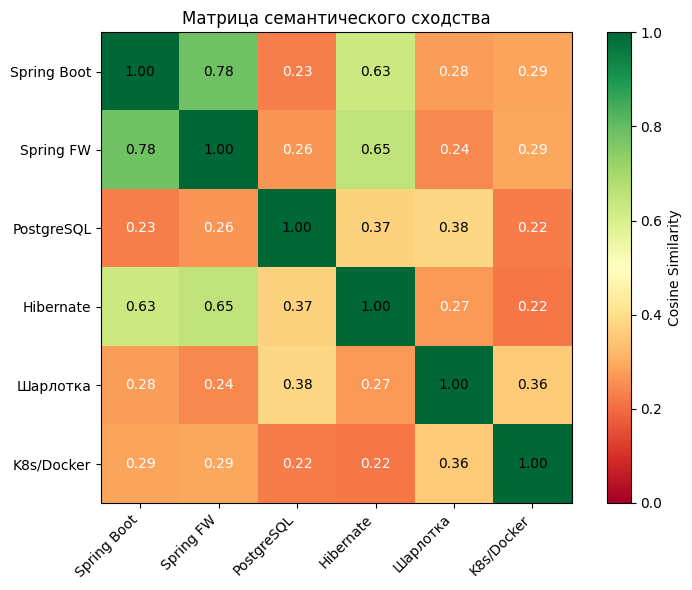

In [4]:
import matplotlib.pyplot as plt

# Визуализация матрицы сходства
sim_matrix = np.array([
    [cosine_similarity(embeddings[i], embeddings[j]) for j in range(len(texts))]
    for i in range(len(texts))
])

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)

# Подписи
short_labels = ["Spring Boot", "Spring FW", "PostgreSQL", "Hibernate", "Шарлотка", "K8s/Docker"]
ax.set_xticks(range(len(texts)))
ax.set_yticks(range(len(texts)))
ax.set_xticklabels(short_labels, rotation=45, ha='right')
ax.set_yticklabels(short_labels)

# Значения в ячейках
for i in range(len(texts)):
    for j in range(len(texts)):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha='center', va='center',
                color='black' if sim_matrix[i,j] > 0.3 else 'white', fontsize=10)

plt.colorbar(im, label='Cosine Similarity')
plt.title('Матрица семантического сходства')
plt.tight_layout()
plt.show()

Обрати внимание:
- Spring Boot ↔ Spring FW: высокое сходство (~0.7-0.8) — смысл близкий
- Hibernate ↔ PostgreSQL: среднее (~0.4-0.5) — обе про данные
- Шарлотка ↔ всё остальное: низкое (~0.05-0.15) — другая тема

---
## 3. Визуализация embedding space

384 измерения невозможно визуализировать. Используем **t-SNE** или **PCA** чтобы сжать до 2D.

```java
// Аналогия: проекция 3D объекта на 2D экран
// Теряем информацию, но видим кластеры
```

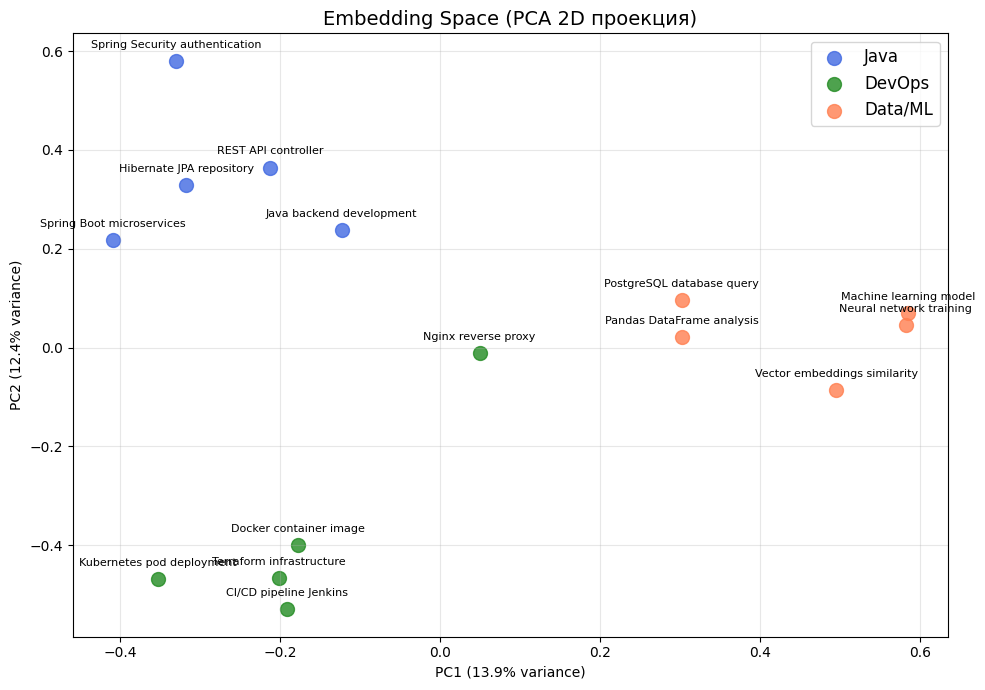

In [5]:
from sklearn.decomposition import PCA

# Больше текстов для красивой визуализации
all_texts = [
    # Java/Spring кластер
    "Spring Boot microservices",
    "Java backend development",
    "Hibernate JPA repository",
    "Spring Security authentication",
    "REST API controller",
    # DevOps кластер
    "Docker container image",
    "Kubernetes pod deployment",
    "CI/CD pipeline Jenkins",
    "Terraform infrastructure",
    "Nginx reverse proxy",
    # Data/ML кластер
    "PostgreSQL database query",
    "Machine learning model",
    "Neural network training",
    "Pandas DataFrame analysis",
    "Vector embeddings similarity",
]

categories = ['Java'] * 5 + ['DevOps'] * 5 + ['Data/ML'] * 5
colors = {'Java': 'royalblue', 'DevOps': 'forestgreen', 'Data/ML': 'coral'}

# Получаем embeddings
all_embeddings = model.encode(all_texts)

# PCA: 384 → 2 измерения
pca = PCA(n_components=2)
coords = pca.fit_transform(all_embeddings)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 7))

for cat in ['Java', 'DevOps', 'Data/ML']:
    mask = [c == cat for c in categories]
    ax.scatter(coords[mask, 0], coords[mask, 1],
              c=colors[cat], label=cat, s=100, alpha=0.8)

# Подписи
for i, text in enumerate(all_texts):
    ax.annotate(text, (coords[i, 0], coords[i, 1]),
               fontsize=8, ha='center', va='bottom',
               xytext=(0, 8), textcoords='offset points')

ax.legend(fontsize=12)
ax.set_title('Embedding Space (PCA 2D проекция)', fontsize=14)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Видно кластеры: Java/Spring, DevOps, Data/ML группируются вместе. Именно это свойство использует RAG для поиска.

---
## 4. Сравнение embedding моделей

### Популярные модели:

| Модель | Размерность | Размер | Язык | Скорость |
|--------|------------|--------|------|----------|
| `all-MiniLM-L6-v2` | 384 | 80MB | EN | Быстрая |
| `all-mpnet-base-v2` | 768 | 420MB | EN | Средняя |
| `multilingual-e5-base` | 768 | 1.1GB | Multi | Средняя |
| `multilingual-e5-large` | 1024 | 2.2GB | Multi | Медленная |
| OpenAI `text-embedding-3-small` | 1536 | API | Multi | Зависит от сети |

### Как выбрать:

```
Только английский текст → all-mpnet-base-v2 (лучшее качество)
                        → all-MiniLM-L6-v2 (быстрее, чуть хуже)

Русский/мультиязычный  → multilingual-e5-base (баланс)
                        → multilingual-e5-large (максимальное качество)

Не хочешь хостить      → OpenAI text-embedding-3-small (API)
```

```java
// Аналогия: выбор БД
// H2 — маленькая, быстрая, для тестов (= MiniLM)
// PostgreSQL — надёжная, универсальная (= mpnet/e5-base)
// Oracle — enterprise, всё умеет (= e5-large)
```

In [6]:
import time

# Бенчмарк: сравниваем модели по скорости и качеству
model_names = [
    "sentence-transformers/all-MiniLM-L6-v2",      # Быстрая, EN
    "sentence-transformers/all-mpnet-base-v2",      # Качественная, EN
]

# Тестовые пары (запрос → ожидаемый результат)
test_pairs = [
    ("How to create REST API in Java?",
     ["Spring Boot REST controller with annotations",
      "Docker container orchestration",
      "Python machine learning tutorial"]),
    ("Database connection pooling",
     ["HikariCP connection pool for PostgreSQL",
      "CSS flexbox layout tutorial",
      "Kafka message broker setup"]),
]

for model_name in model_names:
    print(f"\n{'='*60}")
    print(f"Модель: {model_name.split('/')[-1]}")
    print(f"{'='*60}")
    
    m = SentenceTransformer(model_name)
    
    # Скорость
    start = time.time()
    _ = m.encode(["test"] * 100)
    elapsed = time.time() - start
    print(f"Скорость: 100 текстов за {elapsed:.2f}с")
    print(f"Размерность: {m.get_sentence_embedding_dimension()}")
    
    # Качество: правильный документ должен быть ближе
    for query, candidates in test_pairs:
        q_emb = m.encode(query)
        c_embs = m.encode(candidates)
        sims = [cosine_similarity(q_emb, c) for c in c_embs]
        
        print(f"\n  Запрос: {query}")
        for cand, sim in sorted(zip(candidates, sims), key=lambda x: x[1], reverse=True):
            marker = "✓" if sim == max(sims) else " "
            print(f"  {marker} {sim:.4f} | {cand[:50]}")


Модель: all-MiniLM-L6-v2


Скорость: 100 текстов за 0.10с
Размерность: 384

  Запрос: How to create REST API in Java?
  ✓ 0.3435 | Spring Boot REST controller with annotations
    0.1359 | Docker container orchestration
    0.1106 | Python machine learning tutorial

  Запрос: Database connection pooling
  ✓ 0.5751 | HikariCP connection pool for PostgreSQL
    0.0699 | Kafka message broker setup
    0.0020 | CSS flexbox layout tutorial

Модель: all-mpnet-base-v2


Скорость: 100 текстов за 1.13с
Размерность: 768

  Запрос: How to create REST API in Java?
  ✓ 0.4593 | Spring Boot REST controller with annotations
    0.1430 | Python machine learning tutorial
    0.1338 | Docker container orchestration



  Запрос: Database connection pooling
  ✓ 0.4809 | HikariCP connection pool for PostgreSQL
    0.1096 | Kafka message broker setup
    0.0697 | CSS flexbox layout tutorial


---
## 5. Multilingual embeddings

Для русского текста (как в LegalBPM) нужны **multilingual** модели.

Ключевое свойство: запрос на русском → найдёт документ на английском (и наоборот).  
Это называется **cross-lingual retrieval**.

In [7]:
# Multilingual модель
multi_model = SentenceTransformer('intfloat/multilingual-e5-base')

# Cross-lingual тест: запрос на русском, документы на разных языках
query_ru = "query: Как настроить Spring Security для REST API?"

docs = [
    "passage: Spring Security provides authentication and authorization for REST endpoints",  # EN
    "passage: Настройка Spring Security: фильтры, CORS, JWT токены",                         # RU
    "passage: Docker compose для запуска нескольких контейнеров",                              # RU, другая тема
    "passage: Machine learning model training with TensorFlow",                                # EN, другая тема
]

q_emb = multi_model.encode(query_ru)
d_embs = multi_model.encode(docs)

print(f"Запрос (RU): {query_ru}\n")
print("Результаты:")
sims = [(cosine_similarity(q_emb, d), doc) for d, doc in zip(d_embs, docs)]
for sim, doc in sorted(sims, reverse=True):
    lang = "RU" if any(c in doc for c in 'абвгде') else "EN"
    print(f"  {sim:.4f} [{lang}] {doc[9:60]}...")

Запрос (RU): query: Как настроить Spring Security для REST API?

Результаты:
  0.8607 [EN] Spring Security provides authentication and authori...
  0.8524 [RU] Настройка Spring Security: фильтры, CORS, JWT токен...
  0.7974 [RU] Docker compose для запуска нескольких контейнеров...
  0.7493 [EN] Machine learning model training with TensorFlow...


Обрати внимание: модель нашла и русский, и английский документ про Spring Security — несмотря на разные языки.

> **Важно для `multilingual-e5`:** нужно добавлять префиксы `query:` и `passage:` для лучшего качества.

---
## 6. Embedding через LangChain

В production RAG ты будешь работать через LangChain обёртки, а не напрямую.

In [8]:
from langchain_huggingface import HuggingFaceEmbeddings

# LangChain обёртка — удобный интерфейс
lc_embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}  # L2 нормализация → cosine = dot product
)

# embed_query — для запроса (один текст)
q_vec = lc_embeddings.embed_query("Как работает Spring Boot?")
print(f"embed_query: вектор длины {len(q_vec)}")

# embed_documents — для батча документов
doc_vecs = lc_embeddings.embed_documents([
    "Spring Boot — фреймворк для Java",
    "PostgreSQL — реляционная СУБД",
])
print(f"embed_documents: {len(doc_vecs)} векторов длины {len(doc_vecs[0])}")

# Проверяем similarity
for i, doc in enumerate(["Spring Boot — фреймворк для Java", "PostgreSQL — реляционная СУБД"]):
    sim = cosine_similarity(np.array(q_vec), np.array(doc_vecs[i]))
    print(f"  sim(query, '{doc[:40]}') = {sim:.4f}")

embed_query: вектор длины 384
embed_documents: 2 векторов длины 384
  sim(query, 'Spring Boot — фреймворк для Java') = 0.6170
  sim(query, 'PostgreSQL — реляционная СУБД') = 0.3026


```java
// Java аналогия: LangChain обёртка = Spring Data абстракция

// Без абстракции:
Connection conn = DriverManager.getConnection(url);
PreparedStatement ps = conn.prepareStatement("SELECT ...");

// С Spring Data:
List<User> users = userRepository.findByEmail(email);

// То же самое:
// Без LangChain: model.encode(text) + numpy операции
// С LangChain: embeddings.embed_query(text) → готово
```

---
## 7. Кэширование embeddings

В production embedding одного текста стоит **времени** (CPU/GPU) или **денег** (API).  
Повторные вычисления — пустая трата ресурсов.

```java
// Аналогия: @Cacheable в Spring
@Cacheable("embeddings")
public float[] getEmbedding(String text) {
    return embeddingModel.encode(text); // Тяжёлая операция
}
```

In [9]:
from langchain_classic.embeddings.cache import CacheBackedEmbeddings
from langchain_classic.storage import LocalFileStore
import time
import os

# Создаём кэш на файловой системе
cache_dir = "./embedding_cache"
store = LocalFileStore(cache_dir)

cached_embeddings = CacheBackedEmbeddings.from_bytes_store(
    underlying_embeddings=lc_embeddings,
    document_embedding_cache=store,
    namespace="miniLM"  # Чтобы разные модели не мешали
)

test_docs = [
    "Spring Boot REST API development",
    "Hibernate ORM configuration",
    "Kafka message broker setup",
] * 10  # 30 документов (с повторами)

# Первый запуск — вычисляет embeddings
start = time.time()
vecs1 = cached_embeddings.embed_documents(test_docs)
time1 = time.time() - start

# Второй запуск — из кэша
start = time.time()
vecs2 = cached_embeddings.embed_documents(test_docs)
time2 = time.time() - start

print(f"Первый запуск:  {time1:.3f}с (вычисление)")
print(f"Второй запуск:  {time2:.3f}с (из кэша)")
print(f"Ускорение: {time1/time2:.1f}x")
print(f"Файлов в кэше: {len(os.listdir(cache_dir))}")

Первый запуск:  0.086с (вычисление)
Второй запуск:  0.021с (из кэша)
Ускорение: 4.1x
Файлов в кэше: 3


C:\Users\Ruslan\ai-learning\langchain-academy\lc-academy-env\Lib\site-packages\langchain_classic\embeddings\cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_encoder()


---
## 8. Нормализация и выбор метрики для векторной БД

При создании коллекции в ChromaDB/Qdrant/Pinecone нужно выбрать метрику.

| Метрика | Когда | Примечание |
|---------|-------|------------|
| **Cosine** | По умолчанию | Не зависит от длины вектора |
| **Dot Product** | Нормализованные вектора | Быстрее cosine (нет деления на нормы) |
| **Euclidean (L2)** | Редко | Когда важно абсолютное расстояние |

**Совет:** нормализуй embeddings при создании (`normalize_embeddings=True`) → используй dot product. Это быстрее и эквивалентно cosine для нормализованных векторов.

In [10]:
# Демонстрация: cosine vs dot product для нормализованных векторов

a = model.encode("Spring Boot Java")
b = model.encode("Java Spring framework")

# Без нормализации
cos = cosine_similarity(a, b)
dot = np.dot(a, b)
print("Без нормализации:")
print(f"  Cosine: {cos:.6f}")
print(f"  Dot:    {dot:.6f}")
print(f"  Разные!")

# С нормализацией
a_norm = a / norm(a)
b_norm = b / norm(b)
cos_norm = cosine_similarity(a_norm, b_norm)
dot_norm = np.dot(a_norm, b_norm)
print(f"\nС нормализацией:")
print(f"  Cosine: {cos_norm:.6f}")
print(f"  Dot:    {dot_norm:.6f}")
print(f"  Одинаковые! → Используй dot product (быстрее)")

Без нормализации:


  Cosine: 0.830199
  Dot:    0.830198
  Разные!

С нормализацией:
  Cosine: 0.830199
  Dot:    0.830199
  Одинаковые! → Используй dot product (быстрее)


---
## 9. Production рекомендации

### Чеклист выбора embedding модели:

```
1. Язык данных?
   └─ Только EN → all-mpnet-base-v2
   └─ RU / мульти → multilingual-e5-base (или large)

2. Где запускать?
   └─ Свой сервер (GPU) → локальная модель (HuggingFace)
   └─ Без GPU → API (OpenAI text-embedding-3-small)
   └─ Тесты/dev → all-MiniLM-L6-v2 (быстрая, CPU)

3. Оптимизации:
   └─ Кэшировать embeddings (CacheBackedEmbeddings)
   └─ Нормализовать → dot product вместо cosine
   └─ Батчить запросы (embed_documents, не по одному)
```

### Для LegalBPM:

```python
# Юридические документы на русском → multilingual модель
embeddings = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-base",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)
```

```java
// Java аналогия для production:
@Configuration
class EmbeddingConfig {
    @Bean
    @ConditionalOnProperty(name = "embedding.provider", havingValue = "local")
    EmbeddingService localEmbeddings() {
        return new HuggingFaceEmbeddingService("multilingual-e5-base");
    }

    @Bean
    @ConditionalOnProperty(name = "embedding.provider", havingValue = "openai")
    EmbeddingService openaiEmbeddings(@Value("${openai.api-key}") String key) {
        return new OpenAIEmbeddingService(key, "text-embedding-3-small");
    }
}
```

---
## Итоги

### Что выучили:
- ✅ Embeddings — вектора, кодирующие смысл текста
- ✅ Метрики: cosine similarity, dot product, euclidean
- ✅ Визуализация embedding space через PCA
- ✅ Модели: MiniLM (быстрая), mpnet (качественная), e5 (multilingual)
- ✅ Cross-lingual retrieval для русского текста
- ✅ Кэширование embeddings для production
- ✅ Нормализация → dot product (быстрее cosine)

### Production чеклист:
- [ ] Выбрать модель под язык и инфраструктуру
- [ ] Нормализовать embeddings
- [ ] Кэшировать (файл, Redis, или встроенный кэш БД)
- [ ] Батчить запросы, не по одному
- [ ] Протестировать качество на своих данных (не верить бенчмаркам слепо)

### Следующий модуль:
**Модуль 3 — Vector Stores:** ChromaDB, pgvector, Qdrant. Индексы, фильтрация, персистентность.